# Sensor Count Sweep: Darcy Continuous

- PDE: $-\nabla \cdot (a \nabla u) = 10$, continuous coefficient function
- Latent dimension: $d = 6$
- Sweep: $n_{\mathrm{obs}} \in \{25, 50, 100\}$, clean observations

In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "n_obs": n}
    for s, n in itertools.product([42, 123, 7], [25, 50, 100])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import numpyro

from src.problems.darcy_continuous import DarcyContinuous, mollifier
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, chi2_ppc,
    plot_field_comparison, plot_calibration_overlay,
    plot_sensor_sweep, plot_std_multi_panel,
    plot_sweep_summary_table, plot_trace,
    bootstrap_metric_ci, compute_error_std_correlation,
    tune_sigma, recommended_nuts_config,
    compute_prior_predictive, build_prior_result,
    load_problem, get_nf_mode, make_log_prior,
    make_gaussian_log_likelihood, make_numpyro_model,
    run_map_estimation, compute_sigma_from_map_residual,
    sample_unconditional_prior, decode_posterior_batched,
    run_mcmc, extract_mcmc_diagnostics,
    compute_standard_metrics,
    build_mcmc_result, save_experiment_result,
    load_cross_seed_results,
)

CHECKPOINT_PATH = Path('../runs/final_darcy_continuous/weights/best.pt')
TEST_DATA_PATH = '../data/darcy_continuous/smh_test_in.mat'
TEST_IDX = 0
N_OBS_VALUES = [25, 50, 100]
REF_N_OBS = max(N_OBS_VALUES)
NUM_WARMUP = 5000
NUM_SAMPLES = 2000
NUM_CHAINS = 4
CHAIN_METHOD = 'vectorized'

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]
    N_OBS_VALUES = [PARAMETER_GRID[_task_id]["n_obs"]]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
problem = DarcyContinuous(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)
beta_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

n_points = problem.get_n_points()
print(f"Latent dim: {d}")

Loading data...


  Test: a=(200, 841, 1), u=(200, 841, 1)
Setting up grids and test functions...


  int_grid: (45, 2), v: (45, 1)
Building models...


  Initialized enc: 116,038 params


  Initialized u: 102,006 params
  Initialized a: 102,006 params


E0614 15:33:08.037961      23 hlo_lexer.cc:443] Failed to parse int literal: 894515288310727292233


  Initialized nf: 10,280 params
Loading checkpoint: ../runs/final_darcy_continuous/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded nf


Latent dim: 6


## 2. Sigma Tuning (once, before seed loop)

In [4]:
_rng_setup = random.PRNGKey(0)
_rng_setup, _key = random.split(_rng_setup)

ref_n_obs = REF_N_OBS
_obs_indices_tune = problem.sample_observation_indices(n_points, ref_n_obs, 'random', _key)
_obs_data_tune = problem.prepare_observations(
    sample_indices=[TEST_IDX],
    obs_indices=_obs_indices_tune,
)

_x_full_tune = _obs_data_tune['x_full']
_x_obs_tune = _obs_data_tune['x_obs']
_u_obs_tune = _obs_data_tune['u_obs']
_a_true_tune = _obs_data_tune['a_true']

_log_lik_tune = make_gaussian_log_likelihood(problem, params, mollifier, _x_obs_tune, _u_obs_tune)
_numpyro_model_tune = make_numpyro_model(d, log_prior_fn, _log_lik_tune)


def _model_factory_tune(sigma):
    def _model():
        _numpyro_model_tune(sigma=sigma)
    return _model


def _decode_fn_tune(beta_samples):
    a_preds = []
    for i in range(len(beta_samples)):
        beta_i = beta_samples[i:i+1]
        preds = problem.predict_from_beta(params, jnp.array(beta_i), _x_full_tune)
        a_preds.append(np.array(preds['a_pred'][0, :, 0]))
    return np.stack(a_preds)


_rng_setup, _tune_key = random.split(_rng_setup)
SIGMA_FIXED, _ = tune_sigma(
    model_fn_factory=_model_factory_tune,
    beta_mode=beta_mode,
    sigma_candidates=[0.005, 0.01, 0.02, 0.04, 0.08, 0.15],
    rng_key=_tune_key,
    decode_fn=_decode_fn_tune,
    a_true=np.array(_a_true_tune[0, :, 0]),
    pilot_warmup=2000,
    pilot_samples=500,
    pilot_chains=2,
)
print(f"\nSIGMA_FIXED = {SIGMA_FIXED}  (tune_sigma, tuning obs — used for all sensor count conditions and seeds)")

  Sigma tuning (6 candidates, 2000 warmup + 500 samples × 2 chains):


    sigma=0.0050  cov=0.273  ESS_min=127.7  R-hat=1.031  div=0  OK


    sigma=0.0100  cov=0.879  ESS_min=1.0  R-hat=7.849  div=0  LOW-ESS


    sigma=0.0200  cov=1.000  ESS_min=23.4  R-hat=1.067  div=0  OK


    sigma=0.0400  cov=0.999  ESS_min=1.0  R-hat=4.467  div=0  LOW-ESS


    sigma=0.0800  cov=0.999  ESS_min=85.2  R-hat=1.052  div=6  OK


    sigma=0.1500  cov=0.999  ESS_min=96.1  R-hat=1.027  div=4  OK
  Selected sigma=0.08  (coverage=0.999, ESS_min=85.2)

SIGMA_FIXED = 0.08  (tune_sigma, tuning obs — used for all sensor count conditions and seeds)


## 3. Inversion Config

In [5]:
inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=50.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=25, gamma=0.8),
)


def run_condition(n_obs, rng_key):
    rng_key, obs_key, mcmc_key = random.split(rng_key, 3)
    label = f"n_obs={n_obs}"
    print(f"\n{'='*60}\n  {label}\n{'='*60}")

    obs_indices = problem.sample_observation_indices(n_points, n_obs, 'random', obs_key)
    obs_data = problem.prepare_observations(sample_indices=[TEST_IDX], obs_indices=obs_indices)
    x_obs = obs_data['x_obs']
    u_obs = obs_data['u_obs']

    map_result = run_map_estimation(problem, params, x_obs, u_obs, x_full, inv_config, rng_key)
    a_map = map_result['a_map']
    u_map = map_result['u_map']
    _map_time_s = map_result['time_s']
    map_rmse = float(rmse(a_map, a_true[0]))
    print(f"  MAP RMSE (a): {map_rmse:.6f}")

    sigma = SIGMA_FIXED
    print(f"  sigma (tuned): {sigma:.6f}")

    log_lik_fn = make_gaussian_log_likelihood(problem, params, mollifier, x_obs, u_obs)
    numpyro_model = make_numpyro_model(d, log_prior_fn, log_lik_fn)

    nuts_cfg = recommended_nuts_config(d, sigma)
    print(f"  sigma={sigma} | target_accept_prob={nuts_cfg['target_accept_prob']}, "
          f"max_tree_depth={nuts_cfg['max_tree_depth']}")

    mcmc, timing = run_mcmc(
        numpyro_model, {"beta": beta_mode}, {"sigma": sigma}, mcmc_key,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )
    mcmc.print_summary(exclude_deterministic=True)

    diag = extract_mcmc_diagnostics(mcmc, sample_name="beta", total_samples=NUM_CHAINS * NUM_SAMPLES)
    beta_samples = diag['samples']

    a_pred_all, u_pred_all = decode_posterior_batched(problem, params, beta_samples, x_full)

    metrics = compute_standard_metrics(a_pred_all, a_true_np)

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np, np.mean(a_pred_all, axis=0), np.std(a_pred_all, axis=0),
    )

    u_pred_at_obs = u_pred_all[:, np.array(obs_indices)]
    u_obs_np = np.array(u_obs[0, :, 0])
    chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, sigma)
    print(f"  Chi2 PPC: chi2={chi2_stat:.2f}, p={chi2_pval:.4f} (df={n_obs})")

    return {
        'label': label, 'n_obs': n_obs, 'sigma': sigma,
        'map_a_err': map_rmse, 'a_map': np.array(a_map),
        'u_map': np.array(u_map),
        'x_obs': np.array(x_obs),
        'beta_samples': np.array(beta_samples),
        'beta_by_chain': diag['by_chain'],
        'beta_for_trace': diag['by_chain'][0],
        'a_pred_all': a_pred_all, 'u_pred_all': u_pred_all,
        'a_mean': np.mean(a_pred_all, axis=0),
        'a_std': np.std(a_pred_all, axis=0),
        'u_mean': np.mean(u_pred_all, axis=0),
        'u_std': np.std(u_pred_all, axis=0),
        'ess_min': diag['ess_min'],
        'rhat_max': diag['rhat_max'],
        'rhat_mean': diag['rhat_mean'],
        'n_div': diag['n_div'],
        'reliability_flag': diag['flag'],
        'chi2_ppc': chi2_stat,
        'chi2_ppc_pvalue': chi2_pval,
        'spearman_rho_error_std': spearman_rho,
        'spearman_pvalue_error_std': spearman_p,
        'warmup_time_s': timing['warmup_time_s'],
        'sampling_time_s': timing['sampling_time_s'],
        'step_time_s': timing['step_time_s'],
        'map_time_s': _map_time_s,
        **metrics,
    }

## 4. Per-Seed Loop


######################################################################
# SEED = 7
######################################################################


Prior predictive: a_err=0.2680, CRPS=0.3213, cov95=0.9738

  n_obs=50


  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=50.0, target=u


Inverting:   0%|          | 0/200 [00:00<?, ?it/s]

...

sample: 100%|█████████▉| 1998/2000 [02:19<00:00, 18.46it/s]

sample: 100%|██████████| 2000/2000 [02:19<00:00, 18.65it/s]

sample: 100%|██████████| 2000/2000 [02:19<00:00, 14.30it/s]

MCMC warmup: 464.4s, sampling: 139.9s

                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      0.25      0.12      0.31      0.02      0.36      2.28      2.82
   beta[1]     -0.48      0.13     -0.47     -0.70     -0.27     49.85      1.04
   beta[2]      0.21      0.16      0.17      0.02      0.54      3.17      1.67
   beta[3]     -0.13      0.07     -0.12     -0.25     -0.02      6.51      1.21
   beta[4]     -0.39      0.10     -0.41     -0.54     -0.23      3.72      1.45
   beta[5]     -0.27      0.06     -0.27     -0.39     -0.17    333.82      1.01

Number of divergences: 38
ESS min=2.3, R-hat max=2.8156, divergences=38/8000, [FAIL] ESS_min=2.3 < 10; R-hat_max=2.816 > 1.2


  Chi2 PPC: chi2=0.20, p=1.0000 (df=50)
Saved structured result to: /workspace/experiments/results/structured/sensor_sweep/darcy_continuous_2026-06-14T16-25-24_seed7.json

  Darcy Continuous — Sensor Count Sensitivity
  Condition                  CRPS(a)    Coverage    CI Width   Sharpness   Rel.L2(a)     Diverg.     ESS min       R-hat    Flag
  ------------------------------------------------------------------------------------------------------------------------------
  n_obs=50                  0.035784     99.88%     0.501097    0.128828    0.029051          38         2.3      2.8156  **FAIL
  ** FAIL: chains did not converge — do not draw conclusions from these conditions



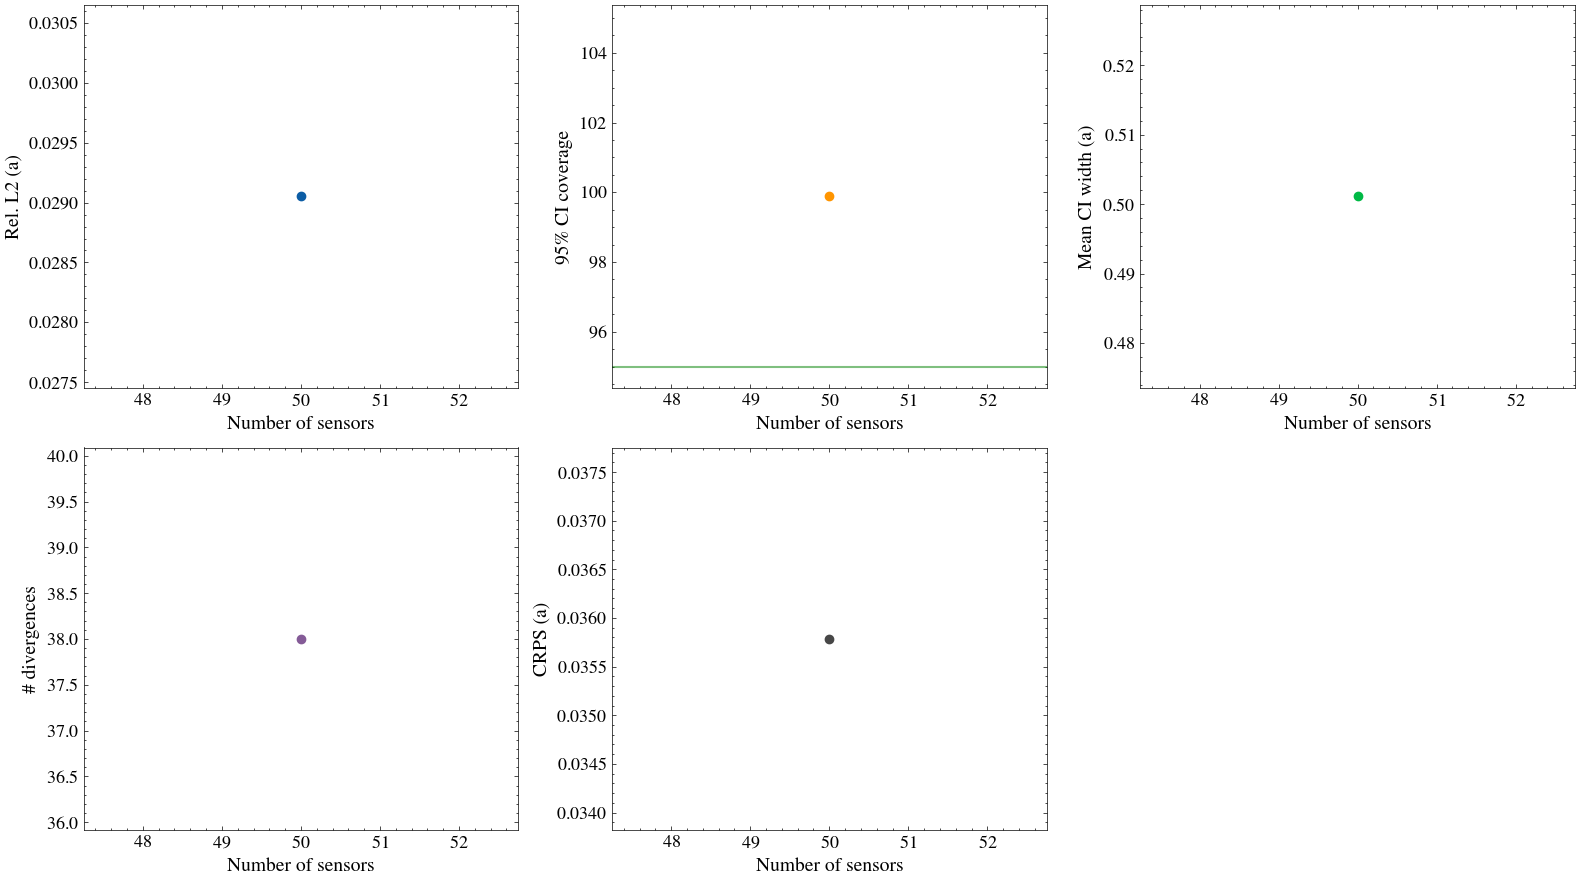

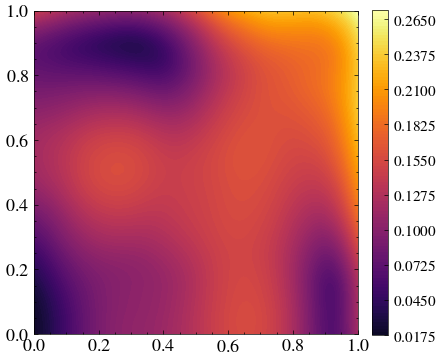

# Panels (a), (b), (c)... correspond to sensor count conditions above


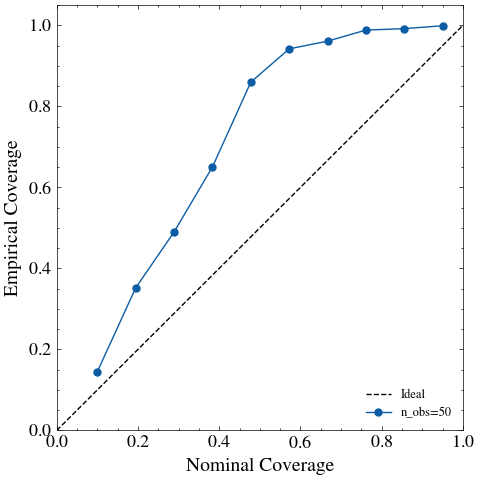

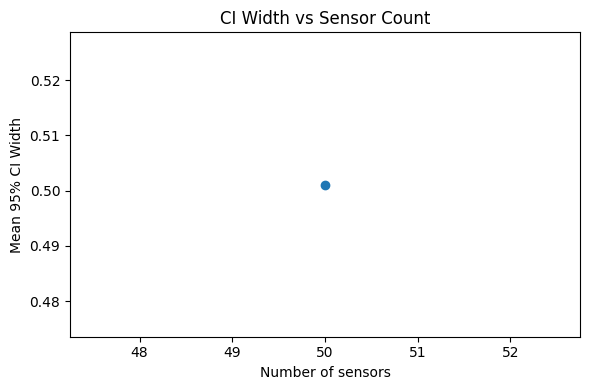

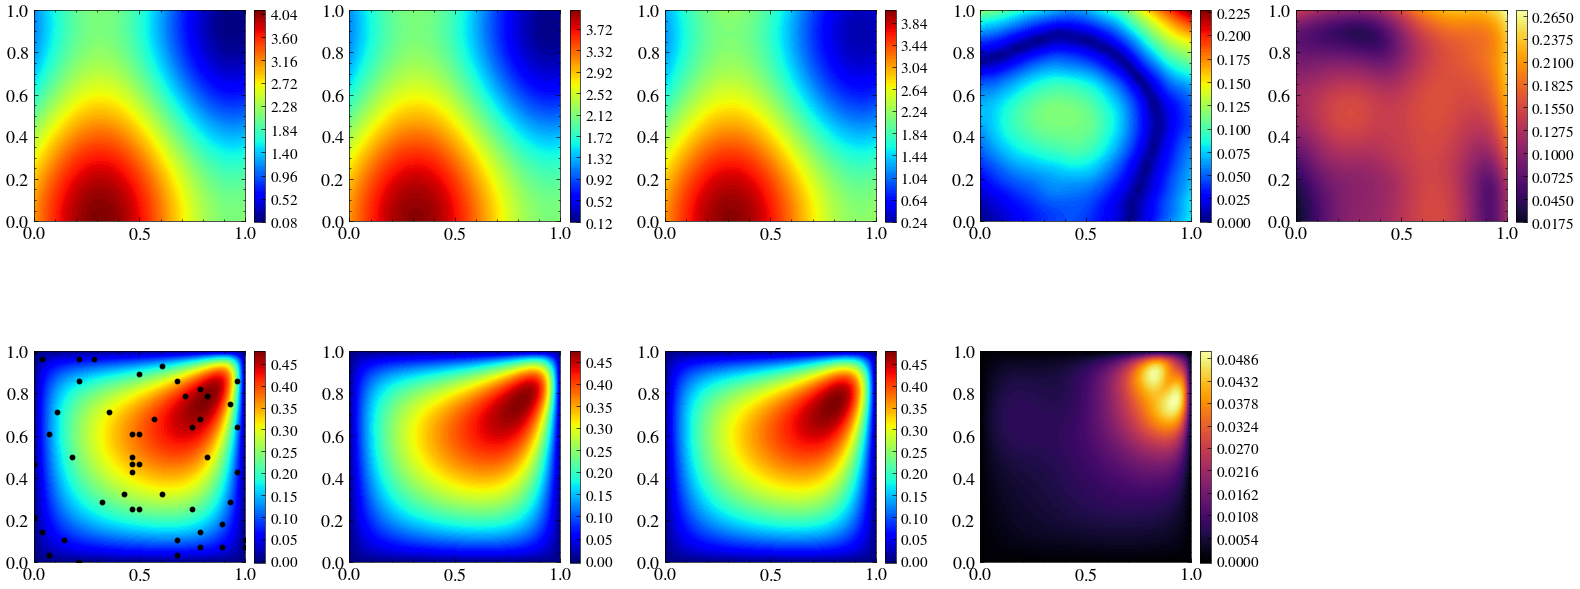

# (a) Ground truth a  (b) MAP a  (c) Posterior mean a  (d) Posterior std a
# (e) Ground truth u  (f) MAP u  (g) Posterior mean u  (h) Posterior std u

Bootstrap CIs on CRPS(a) at each sensor count:
         label      CRPS              95% CI


      n_obs=50  0.03578  [0.03502, 0.03656]

n_obs=50 (sigma=0.080000, 4 chains x 2000 samples):
  ESS:  min=2.3, mean=66.6
  R-hat: max=2.8156, mean=1.5327
  Divergences: 38 / 8000
  MAP RMSE: 0.012571
   dim       ESS     R-hat        mean         std
     0       2.3    2.8156      0.2505      0.1240
     1      49.9    1.0423     -0.4792      0.1334
     2       3.2    1.6687      0.2103      0.1594
     3       6.5    1.2093     -0.1265      0.0708
     4       3.7    1.4486     -0.3899      0.1037
     5     333.8    1.0114     -0.2740      0.0650


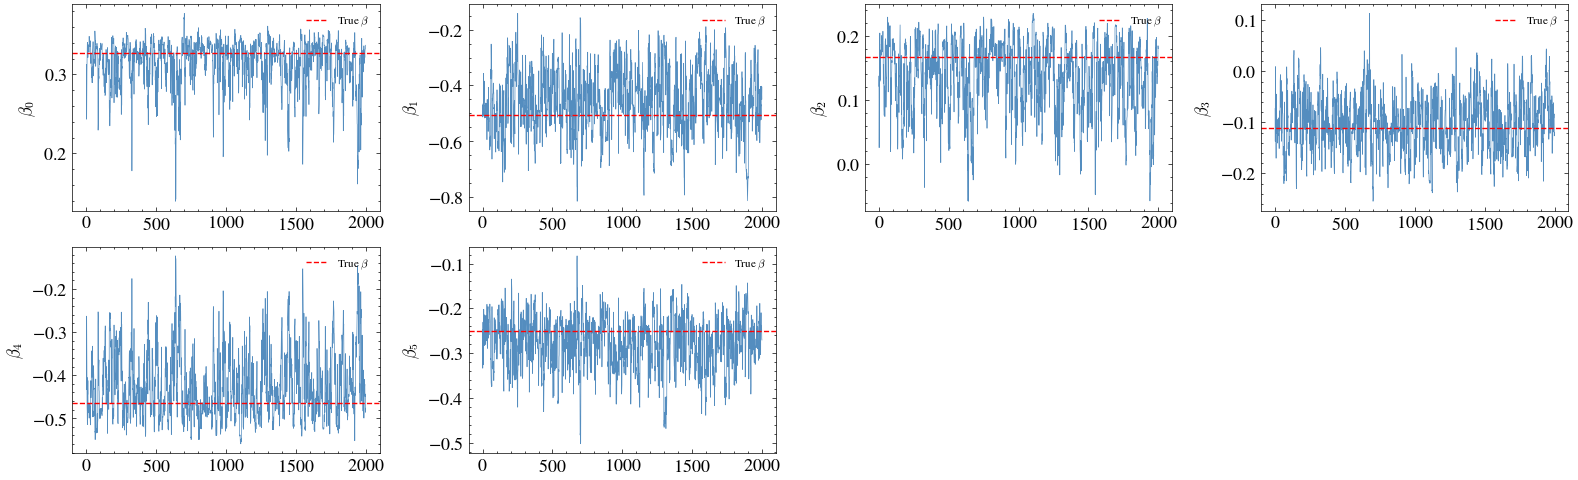

In [6]:
from results_schema import ExperimentResult
from datetime import datetime

def _to_mcmc_result(res):
    return build_mcmc_result(res, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

for SEED in SEEDS:
    _t_total_start = time.time()
    print(f"\n{'#'*70}\n# SEED = {SEED}\n{'#'*70}")

    FIGURE_DIR = Path(f'figures/sensor_sweep_darcy_continuous/seed{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    obs_indices_full = problem.sample_observation_indices(n_points, REF_N_OBS, 'random', key)
    obs_data_full = problem.prepare_observations(sample_indices=[TEST_IDX], obs_indices=obs_indices_full)
    x_full = obs_data_full['x_full']
    a_true = obs_data_full['a_true']
    u_true = obs_data_full['u_true']

    # ### Prior Predictive Baseline
    a_true_np = np.array(a_true[0, :, 0])
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
    )
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}")

    sweep_results = []
    for n_obs in N_OBS_VALUES:
        rng, key = random.split(rng)
        res = run_condition(n_obs, key)
        sweep_results.append(res)

    # ### Save Structured Result

    experiment = ExperimentResult(
        experiment="sensor_sweep",
        problem="darcy_continuous",
        experiment_type="sweep",
        sweep_var="n_obs",
        seed=SEED,
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        baseline=None,
        prior=build_prior_result(prior_metrics),
        sweep_conditions=[_to_mcmc_result(r) for r in sweep_results],
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    # ### Plots

    labels = [f'n_obs={r["n_obs"]}' for r in sweep_results]
    plot_sweep_summary_table(sweep_results, labels, title='Darcy Continuous — Sensor Count Sensitivity')

    plot_sensor_sweep(sweep_results, save_path=FIGURE_DIR / 'sensor_sweep.png')

    x_np = np.array(x_full[0])
    stds = [res['a_std'] for res in sweep_results]
    labels = [res['label'] for res in sweep_results]

    plot_std_multi_panel(
        x_np, stds, labels, grid_shape=(29, 29),
        suptitle='Posterior Std: Sensor Count Sensitivity',
        save_path=FIGURE_DIR / 'std_multi_panel.png',
    )
    print("# Panels (a), (b), (c)... correspond to sensor count conditions above")

    cal_list = [(r['cal_levels'], r['cal_empirical'], r['label']) for r in sweep_results]
    plot_calibration_overlay(cal_list, save_path=FIGURE_DIR / 'calibration_overlay.png')

    with plt.style.context(['default']):
        fig, ax = plt.subplots(figsize=(6, 4))
        n_obs_vals = [r['n_obs'] for r in sweep_results]
        widths = [r['ci_width'] for r in sweep_results]
        ax.plot(n_obs_vals, widths, 'o-', color='C0')
        ax.set_xlabel('Number of sensors')
        ax.set_ylabel('Mean 95% CI Width')
        ax.set_title('CI Width vs Sensor Count')
        plt.tight_layout()
        fig.savefig(FIGURE_DIR / 'ci_width_vs_sensors.png', dpi=200, bbox_inches='tight')
        plt.show()

    x_np = np.array(x_full[0])

    for res in sweep_results:
        plot_field_comparison(
            x_np, a_true_np,
            np.array(res['a_map'][:, 0]),
            res['a_mean'],
            res['a_std'],
            grid_shape=(29, 29),
            u_true=np.array(u_true[0, :, 0]),
            u_map=np.array(res['u_map'][:, 0]),
            u_mean=res['u_mean'],
            u_std=res['u_std'],
            obs_coords=np.array(res['x_obs'][0]),
            save_path=FIGURE_DIR / f'field_comparison_{res["n_obs"]}.png',
        )
        print("# (a) Ground truth a  (b) MAP a  (c) Posterior mean a  (d) Posterior std a")
        print("# (e) Ground truth u  (f) MAP u  (g) Posterior mean u  (h) Posterior std u")

    # ### Statistical Trend Analysis

    def _crps_a(s, t): return float(np.mean(crps_ensemble(s, t)))

    rng_bs = np.random.default_rng(SEED)
    print("\nBootstrap CIs on CRPS(a) at each sensor count:")
    print(f"  {'label':>12s}  {'CRPS':>8s}  {'95% CI':>18s}")
    for res in sweep_results:
        a_np = res['a_pred_all']
        ci = bootstrap_metric_ci(a_np, a_true_np, _crps_a, rng=rng_bs)
        print(f"  {res['label']:>12s}  {ci['estimate']:.5f}  [{ci['ci_lo']:.5f}, {ci['ci_hi']:.5f}]")

    # ### Diagnostics

    from numpyro.diagnostics import effective_sample_size, split_gelman_rubin

    for res in sweep_results:
        beta_by_chain = res['beta_by_chain']
        ess = effective_sample_size(beta_by_chain)
        rhat = split_gelman_rubin(beta_by_chain)
        n_chains, n_samples_per_chain = beta_by_chain.shape[0], beta_by_chain.shape[1]
        total_samples = n_chains * n_samples_per_chain

        print(f"\n{res['label']} (sigma={res['sigma']:.6f}, {n_chains} chains x {n_samples_per_chain} samples):")
        print(f"  ESS:  min={float(ess.min()):.1f}, mean={float(ess.mean()):.1f}")
        print(f"  R-hat: max={float(rhat.max()):.4f}, mean={float(rhat.mean()):.4f}")
        print(f"  Divergences: {res['n_div']} / {total_samples}")
        print(f"  MAP RMSE: {res['map_a_err']:.6f}")

        beta_merged = beta_by_chain.reshape(-1, beta_by_chain.shape[-1])
        print(f"  {'dim':>4s}  {'ESS':>8s}  {'R-hat':>8s}  {'mean':>10s}  {'std':>10s}")
        for i in range(d):
            print(f"  {i:4d}  {float(ess[i]):8.1f}  {float(rhat[i]):8.4f}  "
                  f"{float(beta_merged[:, i].mean()):10.4f}  "
                  f"{float(beta_merged[:, i].std()):10.4f}")

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]
    beta_true_np = np.array(beta_true)

    for res in sweep_results:
        plot_trace(res['beta_for_trace'], beta_true_np, num_warmup=0,
                   save_path=FIGURE_DIR / f'trace_{res["label"]}.png')

## Cross-Seed Aggregation Summary

In [7]:
results = load_cross_seed_results("sensor_sweep", "darcy_continuous")
SUMMARY_METRICS = ["a_err", "crps_a", "nll_a", "coverage_95", "ci_width", "mean_std", "ess_min", "rhat_max", "n_div"]

if len(results) > 1:
    print(f"Cross-Seed Sweep Summary ({len(results)} seeds: {[r.seed for r in results]})\n")

    n_sweep = len(results[0].sweep_conditions) if results[0].sweep_conditions else 0
    for idx in range(n_sweep):
        label = results[0].sweep_conditions[idx].label or f"sweep[{idx}]"
        print(f"\n=== {label} ===")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in SUMMARY_METRICS:
            vals = []
            for r in results:
                if r.sweep_conditions and idx < len(r.sweep_conditions):
                    v = getattr(r.sweep_conditions[idx], m, None)
                    if v is not None:
                        vals.append(float(v))
            if vals:
                arr = np.array(vals)
                std_val = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
                print(f"{m:<16s}  {float(np.mean(arr)):>10.4f}  {std_val:>10.4f}  {float(np.min(arr)):>10.4f}  {float(np.max(arr)):>10.4f}")
else:
    print(f"Only {len(results)} seed result(s) found - skipping cross-seed summary")

Cross-Seed Sweep Summary (27 seeds: [7, 7, 7, 7, 7, 7, 7, 7, 7, 42, 42, 42, 42, 42, 42, 42, 42, 42, 123, 123, 123, 123, 123, 123, 123, 123, 123])


=== n_obs=100 ===
Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.0255      0.0216      0.0089      0.0806
crps_a                0.0377      0.0259      0.0182      0.1047
nll_a                -1.2249      0.4607     -1.8141     -0.3656
coverage_95           0.9978      0.0026      0.9905      0.9988
ci_width              0.4929      0.1869      0.2616      0.8268
mean_std              0.1270      0.0499      0.0677      0.2221
ess_min             364.7689    256.3496      2.2807    648.7413
rhat_max              1.2284      0.5736      1.0033      2.8156
n_div                42.6667     44.6215     13.0000    163.0000
